Datu kopa: 12330 rindas, 28 kolonnas

PageValues statistika:
count    1.233000e+04
mean     1.383052e-16
std      1.000041e+00
min     -3.171778e-01
25%     -3.171778e-01
50%     -3.171778e-01
75%     -3.171778e-01
max      1.916634e+01
Name: PageValues, dtype: float64


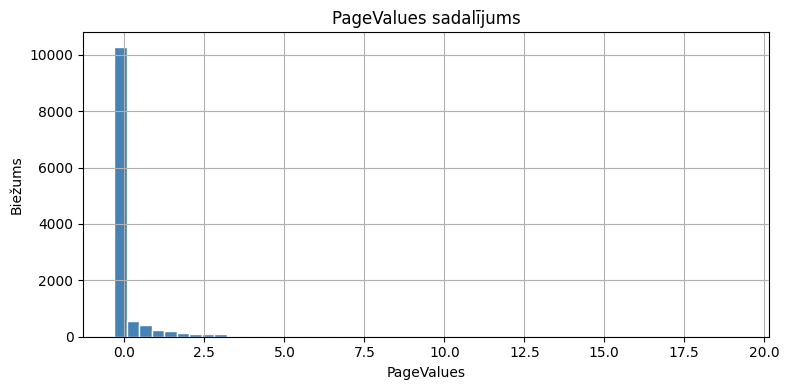


Features skaits: 26
Target: PageValues


In [1]:
# ==============================================================================
# 1. uzdevums. Sagatavo datus regresijai
# ==============================================================================

# --- 1.1. Ielādē datu kopu ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Ielādē 1. nedēļā sagatavoto tīro datu kopu
df = pd.read_csv('shoppers_clean.csv')
print(f"Datu kopa: {df.shape[0]} rindas, {df.shape[1]} kolonnas")

# --- 1.2. Izvēlies target un features ---
# Regresijas uzdevumam mums vajag nepārtrauktu target mainīgo. Izmantosim PageValues:

# Apskatām target mainīgo
print("\nPageValues statistika:")
print(df['PageValues'].describe())

# Attēlojam histogrammu
plt.figure(figsize=(8, 4))
df['PageValues'].hist(bins=50, color='steelblue', edgecolor='white')
plt.title('PageValues sadalījums')
plt.xlabel('PageValues')
plt.ylabel('Biežums')
plt.tight_layout()
plt.show()


# --- 1.3. Sagatavo X un y ---
# # Target
y = df['PageValues']

# # Features – visas kolonnas, izņemot PageValues un Revenue
X = df.drop(['PageValues', 'Revenue'], axis=1)

print(f"\nFeatures skaits: {X.shape[1]}")
print(f"Target: PageValues")

### Kāpēc no *features* tika izņemta kolonna `Revenue`?

Kolonnu `Revenue` (Ieņēmumi) bija obligāti jāizņem no pazīmju (*features*) saraksta, jo pretējā gadījumā modelī rastos **datu noplūde (data leakage)**.

#### Kas ir *data leakage* (datu noplūde)?
Datu noplūde notiek tad, kad mašīnmācīšanās modeļa apmācības procesā tiek izmantota informācija, kas reālajā dzīvē (pēc modeļa ieviešanas ražošanā) tam nebūtu pieejama prognozes veikšanas brīdī.

Šajā konkrētajā gadījumā:
* Mūsu mērķis (*target*) ir prognozēt `PageValues` (lapas vērtību).
* Kolonna `Revenue` parāda, vai lietotājs ir veicis pirkumu un nesis peļņu.
* E-komercijā `PageValues` un `Revenue` ir ļoti cieši saistīti lielumi – ja ir gūti ieņēmumi (`Revenue`), tad arī lapas vērtība (`PageValues`) automātiski būs augsta.

#### Kāpēc tas ir bīstami?
Ja mēs atstātu `Revenue` starp pazīmēm, modelis vienkārši "norakstītu" atbildi no šīs kolonnas, nevis mācītos reālās likumsakarības no lietotāja uzvedības (piemēram, cik laika pavadīts lapā, cik produktu apskatīts).

Tas ir bīstami divu galveno iemeslu dēļ:
1. **Mānīgi labi rezultāti testēšanā:** Modeļa metrikas treniņa un testa fāzē izskatīsies gandrīz perfekti (pārāk labi, lai būtu patiesība).
2. **Nederīgums reālajā dzīvē:** Kad modelis tiks palaists darbībā, lai prognozētu jaunu mājaslapas apmeklētāju uzvedību, mēs vēl **nezināsim**, vai viņi kaut ko nopirks (mums nebūs `Revenue` datu). Bez šī "špikera" modelis apmulsīs un tā precizitāte dramatiski kritīsies.

In [2]:
# --- 1.4. Treniņa/testa sadalījums ---
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"\nTreniņa kopa: {X_train.shape[0]} rindas")
print(f"Testa kopa: {X_test.shape[0]} rindas")


Treniņa kopa: 9864 rindas
Testa kopa: 2466 rindas


In [3]:
# ==============================================================================
# 2. uzdevums. Uztrenē lineārās regresijas modeli
# ==============================================================================

# --- 2.1. Modeļa trenēšana ---
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# Izveido un uztrenē modeli
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# Prognozes
y_pred = lr_model.predict(X_test)

# Metrikas
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("=== Lineāra regresija: rezultāti ===")
print(f"MSE:  {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"MAE:  {mae:.4f}")
print(f"R²:   {r2:.4f}")

=== Lineāra regresija: rezultāti ===
MSE:  0.9892
RMSE: 0.9946
MAE:  0.5009
R²:   0.0456


### 2.2. Modeļa metriku interpretācija

Pēc lineārās regresijas modeļa uztrenēšanas un testēšanas tika iegūti šādi rezultāti:
* **MSE:** 0.9892
* **RMSE:** 0.9946
* **MAE:** 0.5009
* **R²:** 0.0456

Skaidrojums un metriku interpretācija ar saviem vārdiem:

#### 1. Ko nozīmē MAE (Mean Absolute Error)? Cik “tuvu” modelis prognozē vidēji?
MAE ir vidējā absolūtā kļūda. Tā parāda, par cik vienībām vidēji mūsu modeļa prognoze atšķiras no reālās vērtības. Mūsu gadījumā modelis prognozē `PageValues` vidēji ar kļūdu **0.5009**. Tas nozīmē, ka vidēji katrā sesijā modeļa prognozētā lapas vērtība ir par aptuveni pusvienību (0.5) lielāka vai mazāka nekā tā ir īstenībā.

#### 2. Ko nozīmē RMSE (Root Mean Squared Error)? Kāpēc lielākas kļūdas tiek sodītas vairāk?
RMSE ir vidējā kvadrātiskā kļūda, no kuras izvilkta kvadrātsakne. Tā kā aprēķina formulā kļūdas vispirms tiek kāpinātas kvadrātā, **lielas kļūdas (izlecēji jeb *outliers*) ietekmē šo metriku daudz spēcīgāk nekā mazas kļūdas**.
Mūsu gadījumā RMSE ir **0.9946**, kas ir gandrīz divreiz lielāks par MAE (0.5009). Šī lielā atšķirība skaidri norāda, ka datu kopā ir atsevišķi gadījumi, kuros modelis ir pieļāvis lielas kļūdas.

#### 3. Ko nozīmē R² - vērtība, ko esam ieguvuši?
$R^2$ jeb determinācijas koeficients parāda, cik lielu daļu no mērķa mainīgā (`PageValues`) izkliedes spēj izskaidrot mūsu modeļa izmantotās pazīmes (*features*).
Iegūtā vērtība ir **0.0456**, kas nozīmē, ka modelis spēj izskaidrot tikai aptuveni **4.56%** no visas datu mainības. Maksimālā ideālā vērtība būtu 1.0 ( jeb 100%).

#### 4. Vai modelis ir labs vai slikts? Kāpēc tu tā domā?
Modelis ir vērtējams kā **ļoti vājš (slikts)**.
* **Kāpēc?** Galvenais rādītājs ir $R^2 = 0.0456$, kas liecina, ka modelis spēj uztvert mazāk nekā 5% no likumsakarībām un darbojas gandrīz vai minēšanas līmenī. E-komercijas dati (lietotāju uzvedība un pirkumu vērtības) parasti ir nelineāri un sarežģīti, tāpēc vienkāršs "Lineārās regresijas" modelis nespēj tos sekmīgi prognozēt. Rezultātu uzlabošanai nākotnē noteikti jāmēģina izmantot sarežģītāki algoritmi (piemēram, *Random Forest*, *XGBoost*) vai jāveic labāka pazīmju inženierija (*feature engineering*).

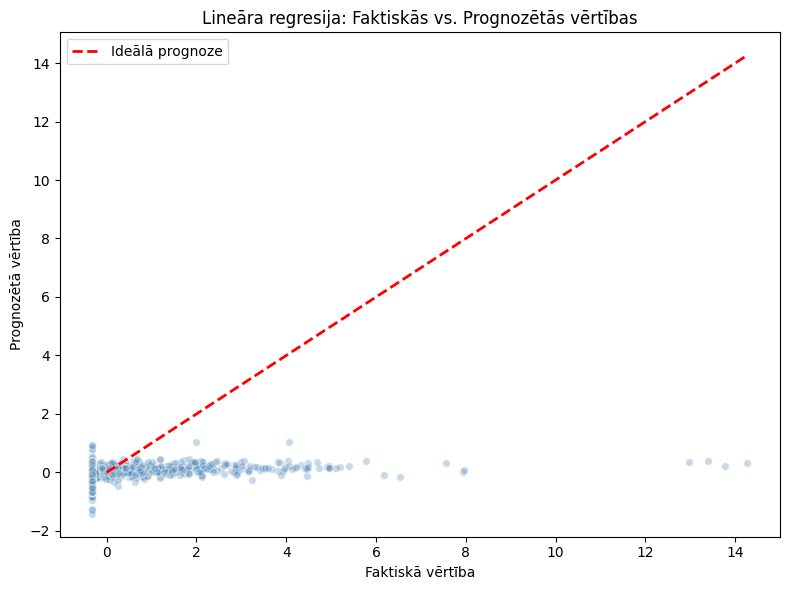

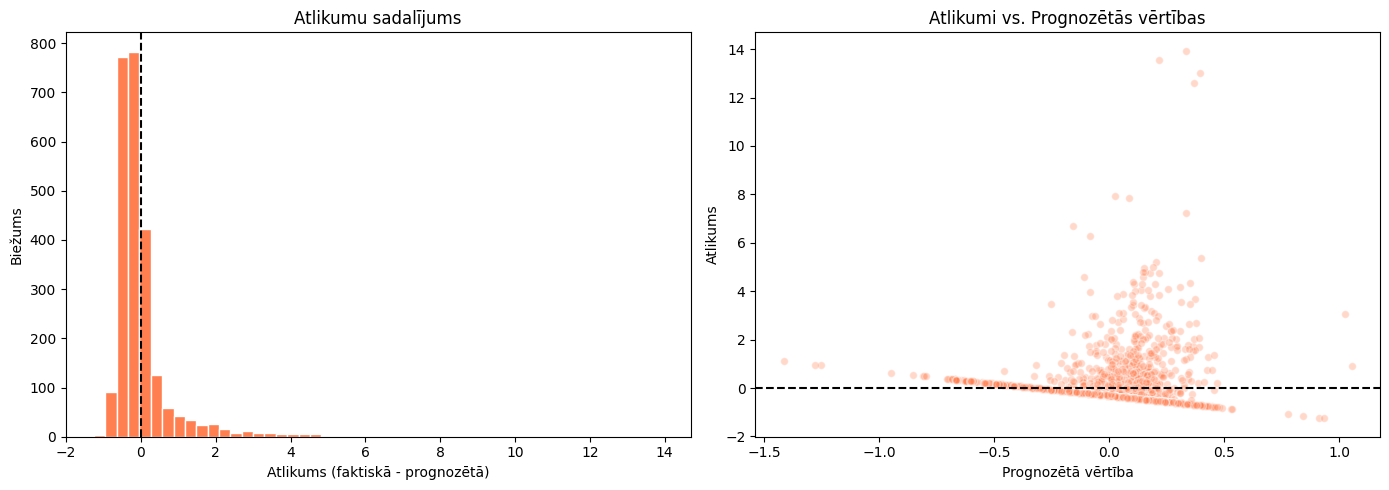

In [4]:
# ==============================================================================
# 3. uzdevums. Vizualizē prognozes
# ==============================================================================

# --- 3.1. Faktiskās vs. prognozētās vērtības ---
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.3, color='steelblue', edgecolors='white', s=30)

# Ideālā līnija (ja prognoze = realitāte)
max_val = max(y_test.max(), y_pred.max())
plt.plot([0, max_val], [0, max_val], 'r--', linewidth=2, label='Ideālā prognoze')

plt.xlabel('Faktiskā vērtība')
plt.ylabel('Prognozētā vērtība')
plt.title('Lineāra regresija: Faktiskās vs. Prognozētās vērtības')
plt.legend()
plt.tight_layout()
plt.show()

# --- 3.2. Atlikumu (residuals) analīze ---
residuals = y_test - y_pred

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Atlikumu sadalījums
axes[0].hist(residuals, bins=50, color='coral', edgecolor='white')
axes[0].set_title('Atlikumu sadalījums')
axes[0].set_xlabel('Atlikums (faktiskā - prognozētā)')
axes[0].set_ylabel('Biežums')
axes[0].axvline(x=0, color='black', linestyle='--')

# Atlikumi vs. prognozētās vērtības
axes[1].scatter(y_pred, residuals, alpha=0.3, color='coral', edgecolors='white', s=30)
axes[1].axhline(y=0, color='black', linestyle='--')
axes[1].set_title('Atlikumi vs. Prognozētās vērtības')
axes[1].set_xlabel('Prognozētā vērtība')
axes[1].set_ylabel('Atlikums')

plt.tight_layout()
plt.show()

### 3.3. Vizualizāciju interpretācija

Balstoties uz ģenerētajiem grafikiem un iepriekš iegūtajiem modeļa rādītājiem ($R^2 = 0.0456$), varam veikt šādu vizualizāciju analīzi:

#### 1. Vai punkti scatter grafikā ir tuvu sarkanajai līnijai? Ko tas nozīmē par modeļa precizitāti?
**Nē, punkti neatrodas tuvu sarkanajai (ideālajai) līnijai.** Tā vietā tie veido diezgan izkliedētu un haotisku klasteri, kur liela daļa punktu ir koncentrēti pie faktiskās vērtības $0$.
Tā kā punkti neslāpējas cieši ap sarkano līniju, tas vizuāli apstiprina, ka **modeļa precizitāte ir ļoti zema**. Modelis nespēj precīzi uzminēt reālo `PageValues` vērtību – tas stipri kļūdās gan uz vienu, gan otru pusi.

#### 2. Vai atlikumi (residuals) ir vienmērīgi sadalīti ap 0? Vai ir kāds bias?
**Atlikumi nav vienmērīgi sadalīti ap nulli, un datos ir izteikts nobīde (*bias*).** * **Atlikumu sadalījuma histogramma** parāda, ka kļūdas nav sadalījušās pēc normālā sadalījuma likuma. Tam ir ļoti augsta smaile vienā vietā, kas liecina par to, ka modelis sistēmiski kļūdās noteiktā virzienā.
* **Atlikumu vs. prognožu grafikā** punkti neveido vienmērīgu "mākoni" ap horizontālo nulles līniju, bet gan izteiktas diagonālas līnijas. Tas nozīmē, ka kļūdas lielums ir tieši atkarīgs no prognozētās vērtības.

Šāds šablons grafikā skaidri norāda uz **lineāro pieņēmumu pārkāpumu (heteroskedastitāti)** un faktu, ka datus nevar adekvāti aprakstīt ar taisnu līniju.

#### 3. Ko vizualizācijas stāsta par modeļa kvalitāti?
Vizualizācijas viennozīmīgi parāda, ka **lineārās regresijas modelis šim e-komercijas uzdevumam ir pilnīgi nepiemērots (zema kvalitāte).** E-komercijas datos mainīgajam `PageValues` ir milzīgs daudzums ar nulles vērtībām (jo lielākā daļa lietotāju sesiju nenes nekādu konkrētu lapas finansiālo vērtību) un daži ļoti lieli "izlecēji" (*outliers*). Lineārā regresija mēģina novilkt vidējo taisni caur šiem datiem, kā rezultātā tā nespēj prognozēt ne nulles, ne arī lielās vērtības. Lai modeli uzlabotu, ir nepieciešams pāriet uz sarežģītākiem, nelineāriem algoritmiem (piemēram, koku ansambļiem) vai jāveic datu transformācija.

=== Polinomiālā regresija (degree=2): rezultāti ===
MAE:  0.4888
RMSE: 0.9993
R²:   0.0364

=== Modeļu salīdzinājuma tabula (Testa dati) ===
         Lineārā regresija  Polinomiālā regresija
Metrika                                          
MAE                 0.5009                 0.4888
RMSE                0.9946                 0.9993
R²                  0.0456                 0.0364


=== Overfitting pārbaude (R² train vs. test) ===
Lineārā regresija -> Train R²: 0.0568 | Test R²: 0.0456
Polinomiālā regresija -> Train R²: 0.1334 | Test R²: 0.0364

✅ Polinomiālās regresijas modelim nav kritiska overfitting (starpība < 0.10).




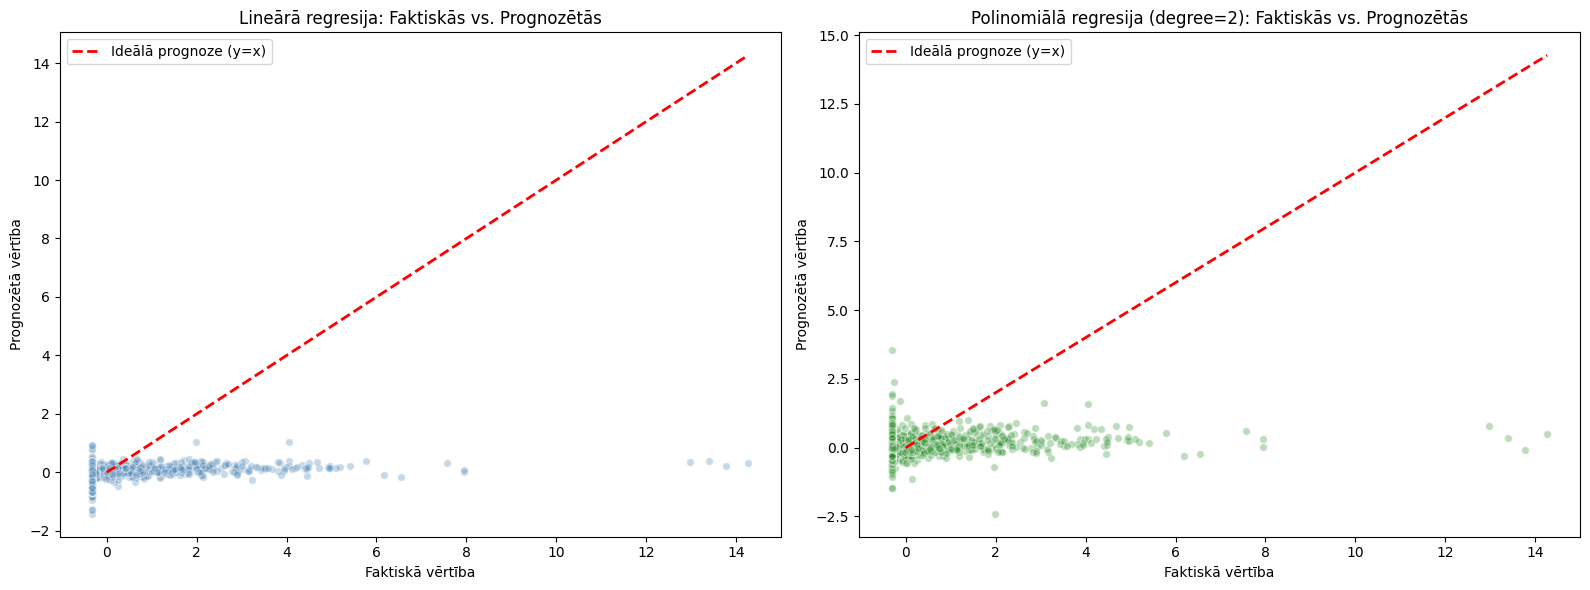

In [5]:
# ==============================================================================
# 4. uzdevums. Izmēģinam polinomiālo regresiju
# ==============================================================================

# --- 4.1. PolynomialFeatures ar degree=2 ---
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline

# Izveidojam pipeline: PolynomialFeatures -> LinearRegression
poly_pipeline = Pipeline([
    ('poly', PolynomialFeatures(degree=2, include_bias=False)),
    ('lr', LinearRegression())
])

# Trenēšana
poly_pipeline.fit(X_train, y_train)

# Prognozes
y_pred_poly = poly_pipeline.predict(X_test)

# Metrikas (Testa datiem)
mae_poly = mean_absolute_error(y_test, y_pred_poly)
rmse_poly = np.sqrt(mean_squared_error(y_test, y_pred_poly))
r2_poly = r2_score(y_test, y_pred_poly)

print("=== Polinomiālā regresija (degree=2): rezultāti ===")
print(f"MAE:  {mae_poly:.4f}")
print(f"RMSE: {rmse_poly:.4f}")
print(f"R²:   {r2_poly:.4f}\n")

# --- 4.2. Salīdzinājuma tabula
# Izveidojam DataFrame, kurā apkopotas abu modeļu metrikas uz testa datiem
metrikas_data = {
    'Metrika': ['MAE', 'RMSE', 'R²'],
    'Lineārā regresija': [mae, rmse, r2],
    'Polinomiālā regresija': [mae_poly, rmse_poly, r2_poly]
}
df_metrikas = pd.DataFrame(metrikas_data).set_index('Metrika')

print("=== Modeļu salīdzinājuma tabula (Testa dati) ===")
print(df_metrikas.round(4))
print("\n" + "="*50 + "\n")


# --- 4.3. Pārbaudam overfitting (train vs. test)
# Aprēķinām R² gan uz train, gan uz test datiem abiem modeļiem
r2_lr_train = lr_model.score(X_train, y_train)
r2_lr_test = r2 # jau aprēķināts iepriekšējos uzdevumos

r2_poly_train = poly_pipeline.score(X_train, y_train)
r2_poly_test = r2_poly

print("=== Overfitting pārbaude (R² train vs. test) ===")
print(f"Lineārā regresija -> Train R²: {r2_lr_train:.4f} | Test R²: {r2_lr_test:.4f}")
print(f"Polinomiālā regresija -> Train R²: {r2_poly_train:.4f} | Test R²: {r2_poly_test:.4f}\n")

# Loģika, kas brīdina, ja starpība starp train un test R² pārsniedz 0.10
if abs(r2_lr_train - r2_lr_test) > 0.10:
    print("⚠️ BRĪDINĀJUMS: Lineārās regresijas modelim ir novērojams overfitting!")

if abs(r2_poly_train - r2_poly_test) > 0.10:
    print("⚠️ BRĪDINĀJUMS: Polinomiālās regresijas modelim ir novērojams izteikts overfitting!")
else:
    print("✅ Polinomiālās regresijas modelim nav kritiska overfitting (starpība < 0.10).")
print("\n" + "="*50 + "\n")


# --- 4.4. Vizuāls salīdzinājums (TODO)
# Izveidojam grafiku ar diviem scatter grafikiem blakus (1 rinda, 2 kolonnas)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Nosakām kopējo max vērtību ideālajai līnijai
max_val = max(y_test.max(), y_pred.max(), y_pred_poly.max())

# 1. grafiks: Lineārā regresija
axes[0].scatter(y_test, y_pred, alpha=0.3, color='steelblue', edgecolors='white', s=30)
axes[0].plot([0, max_val], [0, max_val], 'r--', linewidth=2, label='Ideālā prognoze (y=x)')
axes[0].set_title('Lineārā regresija: Faktiskās vs. Prognozētās')
axes[0].set_xlabel('Faktiskā vērtība')
axes[0].set_ylabel('Prognozētā vērtība')
axes[0].legend()

# 2. grafiks: Polinomiālā regresija
axes[1].scatter(y_test, y_pred_poly, alpha=0.3, color='forestgreen', edgecolors='white', s=30)
axes[1].plot([0, max_val], [0, max_val], 'r--', linewidth=2, label='Ideālā prognoze (y=x)')
axes[1].set_title('Polinomiālā regresija (degree=2): Faktiskās vs. Prognozētās')
axes[1].set_xlabel('Faktiskā vērtība')
axes[1].set_ylabel('Prognozētā vērtība')
axes[1].legend()

plt.tight_layout()
plt.show()

### 4.5. Secinājumi par polinomiālo regresiju

Balstoties uz eksperimenta rezultātiem un modeļu salīdzinājuma tabulu, varam izdarīt šādus secinājumus:

1. **Kurš modelis labāk prognozē PageValues? Kāpēc?**
Neviens no modeļiem neprognozē datus labi, taču **vienkāršā lineārā regresija ir nedaudz stabilāka**. Skatoties uz testa datiem, polinomiālajam modelim ir minimāli labāks MAE (0.4888 pret 0.5009), taču tā RMSE ir pieaudzis un kopējais $R^2$ rādītājs ir sliktāks nekā lineārajai regresijai. Tas liecina, ka nelineāro pazīmju ($x^2$) pievienošana nav sniegusi reālu labumu prognožu kvalitātei uz jauniem datiem.

2. **Vai polinomiālais modelis nopietni uzlaboja R²? Vai uzlabojums ir spēle?**
Polinomiālais modelis nevis uzlaboja, bet gan **pasliktināja $R^2$ rādītāju uz testa datiem**, tam nokrītot no jau tā zemā 0.0456 uz 0.0364. Tas skaidri parāda, ka jebkurš šķietamais progress bija tikai matemātiska "spēle" un ilūzija uz treniņa datiem, kur polinomiālais modelis spēja sasniegt $R^2 = 0.1334$.

3. **Vai ir overfitting pazīmes (liela Train-Test atšķirība)?**
Koda automātiskā pārbaude ziņo, ka kritiska *overfitting* robeža (starpība > 0.10) nav pārsniegta (starpība ir $0.1334 - 0.0364 = 0.0970$, kas ir mata tiesu no brīdinājuma). Tomēr **vieglas overfitting pazīmes ir skaidri saskatāmas**: polinomiālais modelis uzrāda salīdzinoši daudz labāku rezultātu treniņa fāzē (izskaidro 13.34% mainības), bet, saskaroties ar testa datiem, tā precizitāte strauji krītas līdz 3.64%.

4. **Ko tu ieteiktu izmantot biznesa vidē — lineāro vai polinomiālo?**
Biznesa vidē es **stingri neieteiktu izmantot nevienu no šiem modeļiem**, jo prognozēt tikai 3.6% vai 4.5% no lapas vērtības izmaiņām nozīmē darboties gandrīz pilnīgā minējumu līmenī. Ja izvēle būtu obligāta, drošāka būtu vienkāršā lineārā regresija, jo tā mazāk tiecas pārlāgoties. Tomēr reālam biznesam pareizais ieteikums ir atteikties no regresijas taisnēm un pāriet uz koku ansambļu algoritmiem (piemēram, *Random Forest* vai *XGBoost*), kas ir daudz piemērotāki e-komercijas datu struktūrai.